In [1]:
# instalamos el paquete para descargar archivos wget
!pip install wget scipy
!pip install --upgrade numpy

# importamos wget y las librerías que nos faltan
from wget import download
from os import path, listdir

# descargamos una base de datos en Excel
if not path.exists("itunes_data.xlsx"):
  download("https://github.com/PacktPublishing/Practical-Data-Science-with-Python/raw/main/4-Chapter-4/data/itunes_data.xlsx")
else:
  print("No vamos a bajar el archivo de itunes porque ya existe!")

# y una en CSV
if not path.exists("housing_pandas.csv"):
  download("https://ignaciorlando.github.io/datasets/housing_pandas.csv")
else:
  print("No vamos a bajar el archivo de casas porque ya existe!")

# chequeamos si los archivos están en el directorio donde estamos parados
lista_archivos = listdir("./")
print(f"El contenido de la carpeta es: {lista_archivos}")


No vamos a bajar el archivo de itunes porque ya existe!
No vamos a bajar el archivo de casas porque ya existe!
El contenido de la carpeta es: ['.git', '.gitignore', '.prac', 'Colab_clase3.ipynb', 'ejercicio.ipynb', 'Ejercicio2.ipynb', 'Ejercicio2_2.ipynb', 'housing_pandas.csv', 'itunes_data.xlsx', 'netflix_titles.csv', 'netflix_titles.txt']


In [2]:
import pandas as pd

# abrimos el archivo usando una función específica de pandas
raw_dataset = pd.read_csv("housing_pandas.csv")
# cambiamos a CHAS para que sea booleano
raw_dataset["CHAS"] = raw_dataset["CHAS"].astype(bool)
# cambiamos las columnas que son porcentajes
raw_dataset["ZN"] = raw_dataset["ZN"] / 100
raw_dataset["INDUS"] = raw_dataset["INDUS"] / 100
raw_dataset["AGE"] = raw_dataset["AGE"] / 100
raw_dataset["LSTAT"] = raw_dataset["LSTAT"] / 100
# mostramos como quedan las columas imprimiendo el info
print(raw_dataset.info())
# y el summary
raw_dataset.describe()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    bool   
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: bool(1), float64(13)
memory usage: 52.0 KB
None


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,0.113636,0.111368,0.554695,6.284634,0.685749,3.795043,9.549407,408.237154,18.455534,356.674032,0.126531,22.532806
std,8.601545,0.233225,0.068604,0.115878,0.702617,0.281489,2.105710,8.707259,168.537116,2.164946,91.294864,0.071411,9.197104
min,0.006320,0.000000,0.004600,0.385000,3.561000,0.029000,1.129600,1.000000,187.000000,12.600000,0.320000,0.017300,5.000000
25%,0.082045,0.000000,0.051900,0.449000,5.885500,0.450250,2.100175,4.000000,279.000000,17.400000,375.377500,0.069500,17.025000
50%,0.256510,0.000000,0.096900,0.538000,6.208500,0.775000,3.207450,5.000000,330.000000,19.050000,391.440000,0.113600,21.200000
75%,3.677083,0.125000,0.181000,0.624000,6.623500,0.940750,5.188425,24.000000,666.000000,20.200000,396.225000,0.169550,25.000000
max,88.976200,1.000000,0.277400,0.871000,8.780000,1.000000,12.126500,24.000000,711.000000,22.000000,396.900000,0.379700,50.000000


In [3]:
import numpy as np
from scipy import stats

variable_1 = "TAX"
variable_2 = "MEDV"

# Extraer las columnas del DataFrame
datos_columna1 = raw_dataset[variable_1]
datos_columna2 = raw_dataset[variable_2]

# calcular la correlación de Pearson usando NumPy
#coeficiente_correlacion = np.corrcoef(datos_columna1, datos_columna2)[0, 1]
#print(coeficiente_correlacion)

# alternativamente, se puede usar SciPy:
coeficiente_correlacion, _ = stats.pearsonr(datos_columna1, datos_columna2)
print(f"Correlación entre {variable_1} y {variable_2}: {coeficiente_correlacion:.4f}")

Correlación entre TAX y MEDV: -0.4685


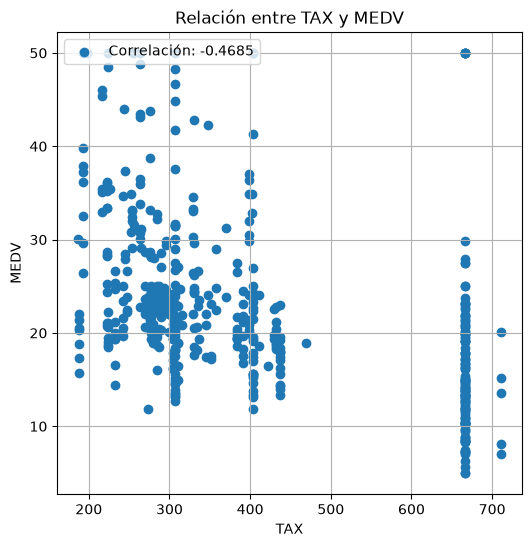

In [4]:
!pip install wget matplotlib
!pip install --upgrade numpy
import matplotlib.pyplot as plt

variable_1 = "TAX"
variable_2 = "MEDV"
# variable_1 = "LSTAT"
# variable_2 = "CRIM"
# en clase, mostrar también este ejemplo
#variable_1 = "CHAS"
#variable_2 = "NOX"

# creamos el scatter plot
plt.figure(figsize=(6, 6))  # con esta línea podemos ajustar el tamaño de la gráfica
plt.scatter(raw_dataset[variable_1], raw_dataset[variable_2])
plt.xlabel(variable_1)
plt.ylabel(variable_2)
plt.title("Relación entre {} y {}".format(variable_1, variable_2))

# calcular la correlación de Pearson usando SciPy
coeficiente_correlacion, _ = stats.pearsonr(raw_dataset[variable_1], raw_dataset[variable_2])
# agregar la leyenda con el valor del coeficiente de correlación
plt.legend([f"Correlación: {coeficiente_correlacion:.4f}"], loc="upper left")

# Mostrar el gráfico
plt.grid(True)
plt.show()

In [5]:
# calculamos las correlaciones entre features e imprimimos la matriz
correlation_matrix = raw_dataset.corr()
correlation_matrix

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


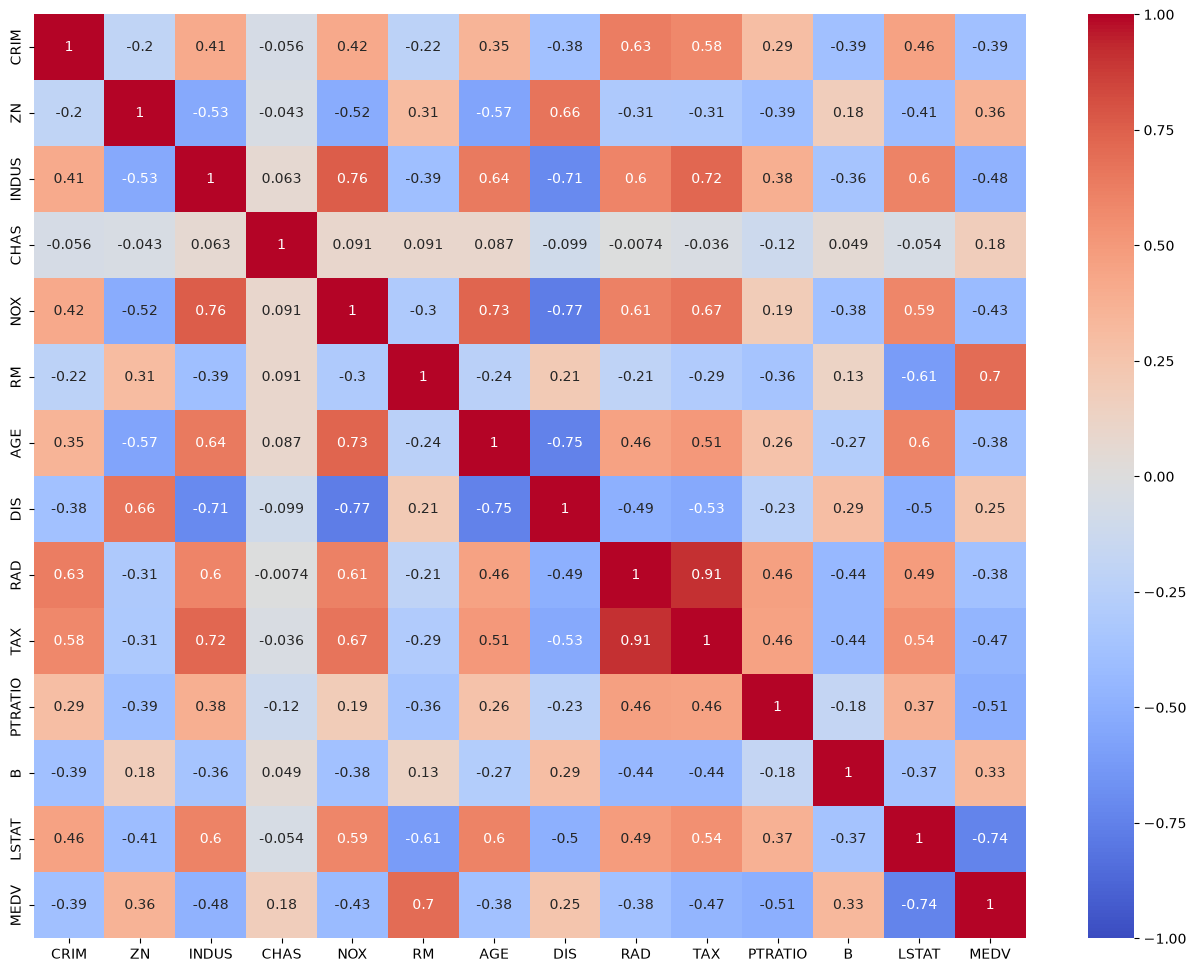

In [6]:

!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# imprimimos la matriz como un heatmap
plt.figure(figsize=(16,12))
sns.heatmap(correlation_matrix, vmin=-1.0, vmax=1.0, center=0.0, annot=True, cmap= 'coolwarm')
plt.show()

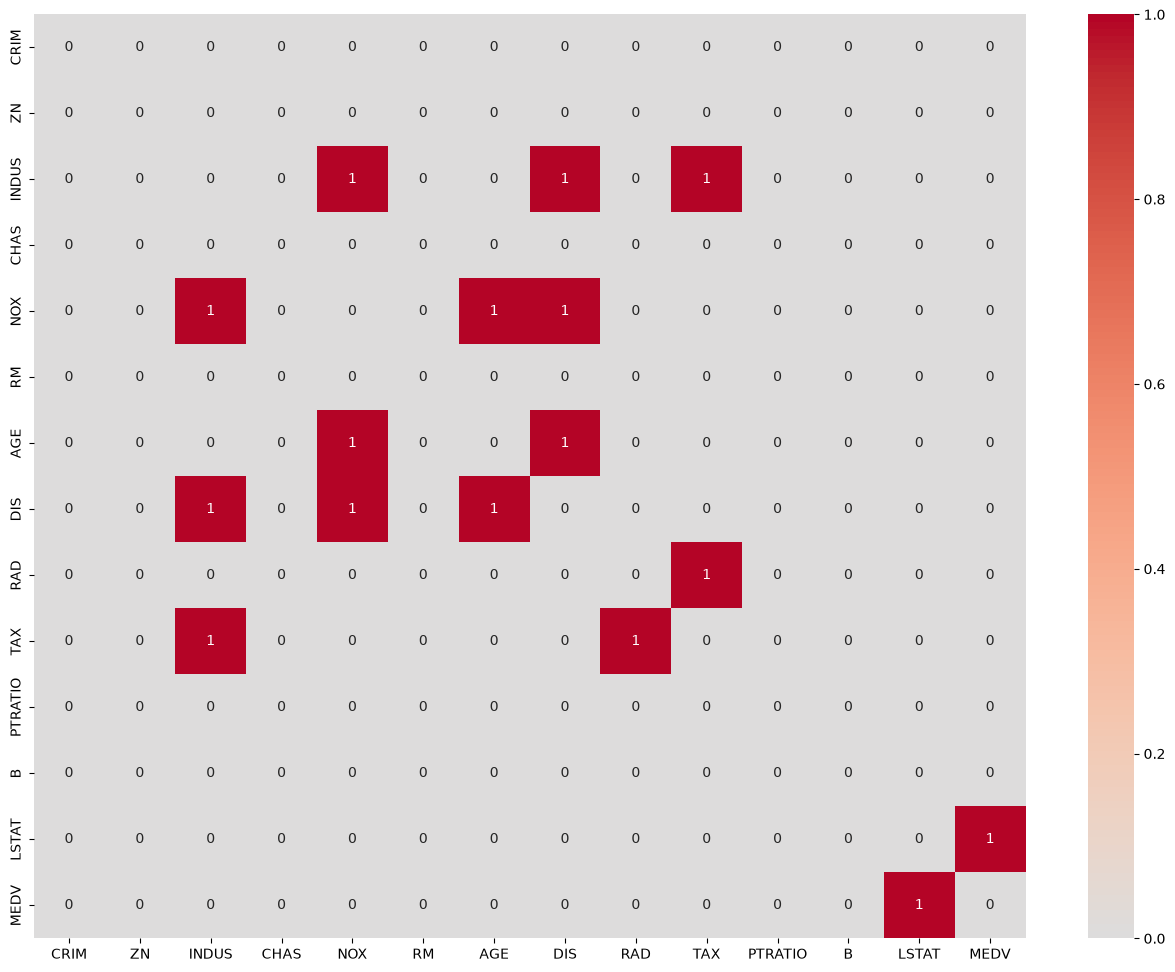

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# tomamos el valor absoluto de las correlaciones, umbralamos las mayores a 0.7
correlation_matrix_umbralizada = correlation_matrix.abs() > 0.7
# aprovechamos y sacamos la diagonal
# aprovechamos y sacamos la diagonal
mask_diagonal = np.eye(correlation_matrix_umbralizada.shape[0], dtype=bool)
correlation_matrix_umbralizada = correlation_matrix_umbralizada.mask(mask_diagonal, False)

# e imprimimos la matriz como un heatmap
plt.figure(figsize=(16,12));
sns.heatmap(correlation_matrix_umbralizada, vmin=0.0, vmax=1.0, center=0.0, annot=True, cmap= 'coolwarm')
plt.show()

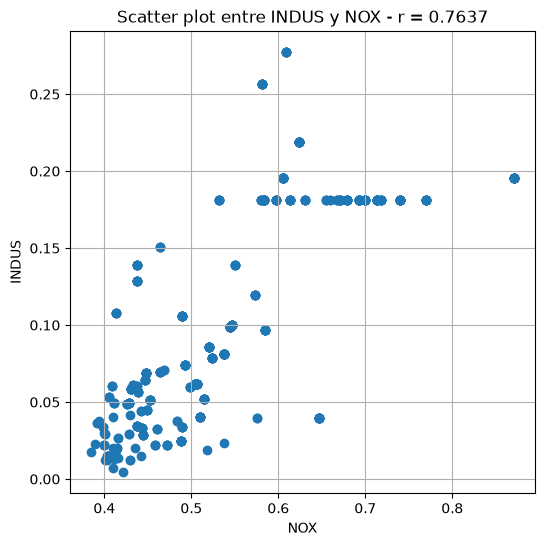

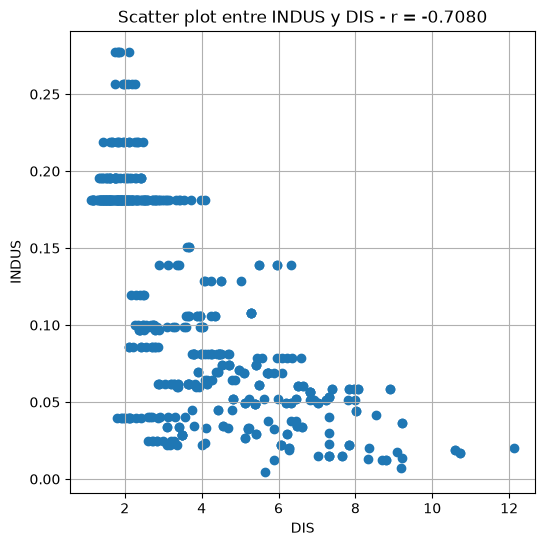

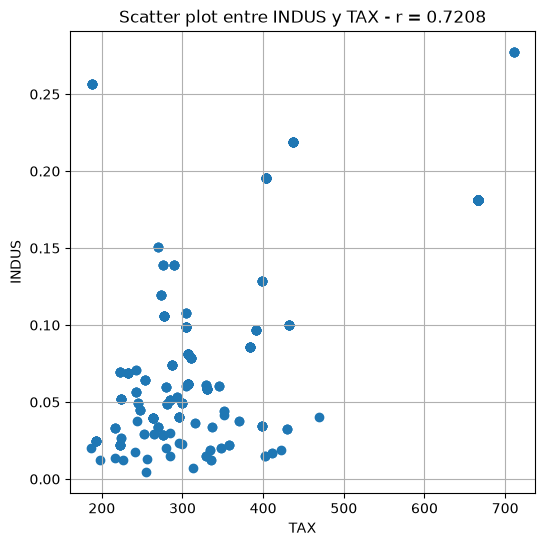

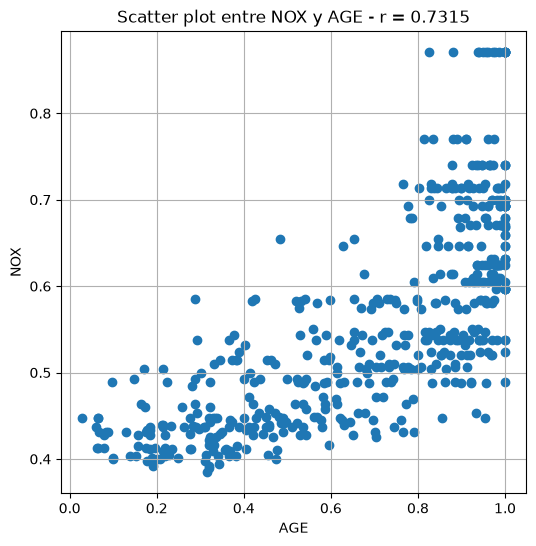

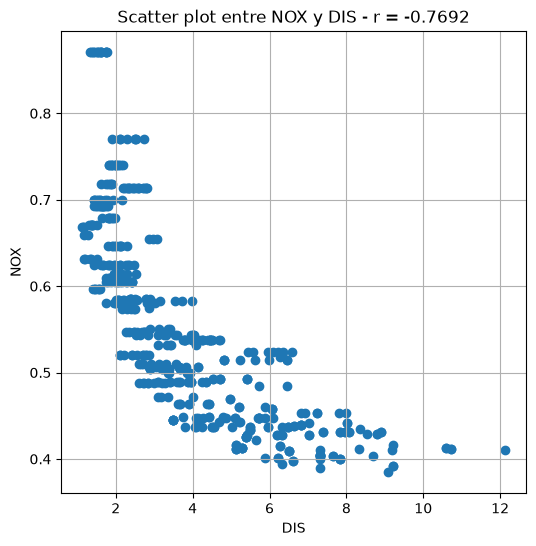

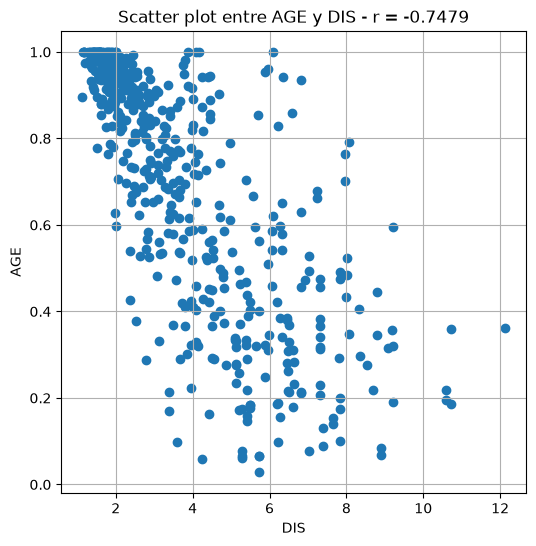

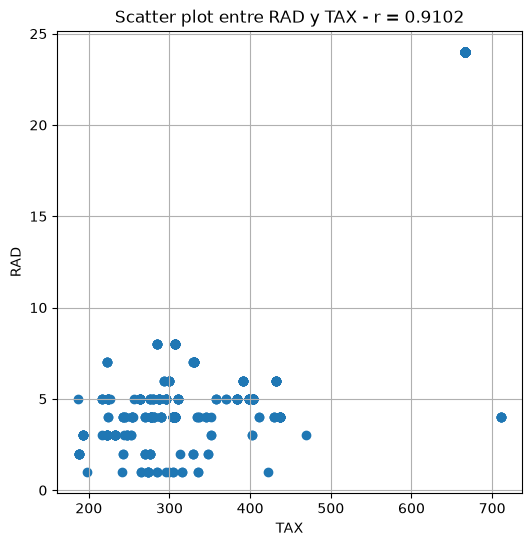

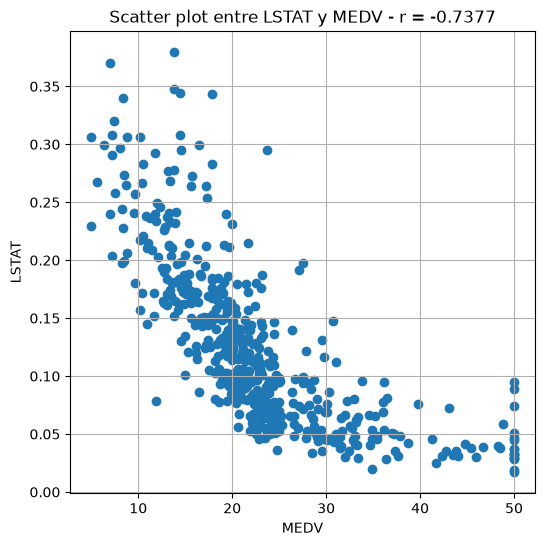

In [8]:
# iteramos por cada una de las columnas
for i, col in enumerate(correlation_matrix_umbralizada.columns):
  # y por cada una de las filas (para eso usamos el índice)
  for j in range(i,len(correlation_matrix_umbralizada.index)):
    # extraemos el nombre de la fila en la que estamos
    row = correlation_matrix_umbralizada.index[j]
    # si en esa posición tenemos un True en la matriz umbralizada
    if correlation_matrix_umbralizada.loc[row, col]:
      # nos traemos el valor de esa correlación
      correlation = correlation_matrix.loc[row, col]
      # representamos en un scatter plot cuadrado los valores de ambas variables
      plt.figure(figsize=(6, 6))
      plt.scatter(raw_dataset[row], raw_dataset[col])
      # y lo mostramos bonito
      plt.title(f"Scatter plot entre {col} y {row} - r = {correlation:.4f}")
      plt.xlabel(row)
      plt.ylabel(col)
      plt.grid(True)
      plt.show()

c:\Users\ferre\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Using cached sweetviz-2.3.3-py3-none-any.whl.metadata (22 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
Using cached sweetviz-2.3.3-py3-none-any.whl (15.1 MB)
Using cached importlib_resources-7.1.0-py3-none-any.whl (37 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl (15 kB)
Using cached tqdm-4.70.0-py3-none-any.whl (80 kB)

   ---------------------------------------- 0/5 [tqdm]
   -------- ------------------------------- 1/5 [MarkupSafe]
   ---------------- ----------------------- 2/5 [importlib_resources]
   ------------------------ --------------- 3/5 [jinja2]
   ------------------------ --------------- 3/5 [jinja2]
   -------------------------------- ------- 4/5 [sweetviz]
   ------------

Feature: CRIM                                |▋         | [  7%]   00:00 -> (00:00 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: ZN                                  |█▎        | [ 13%]   00:00 -> (00:02 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal,


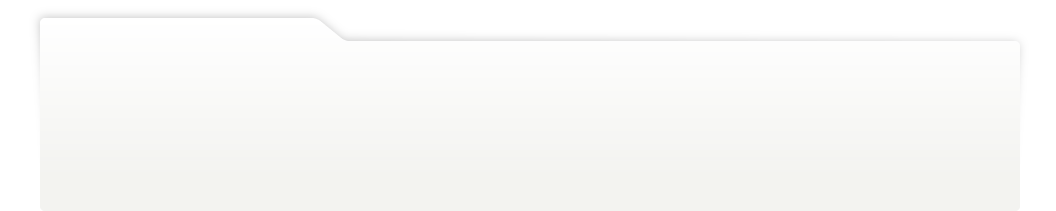
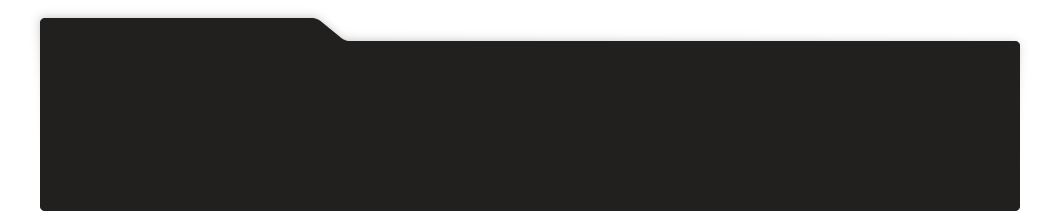
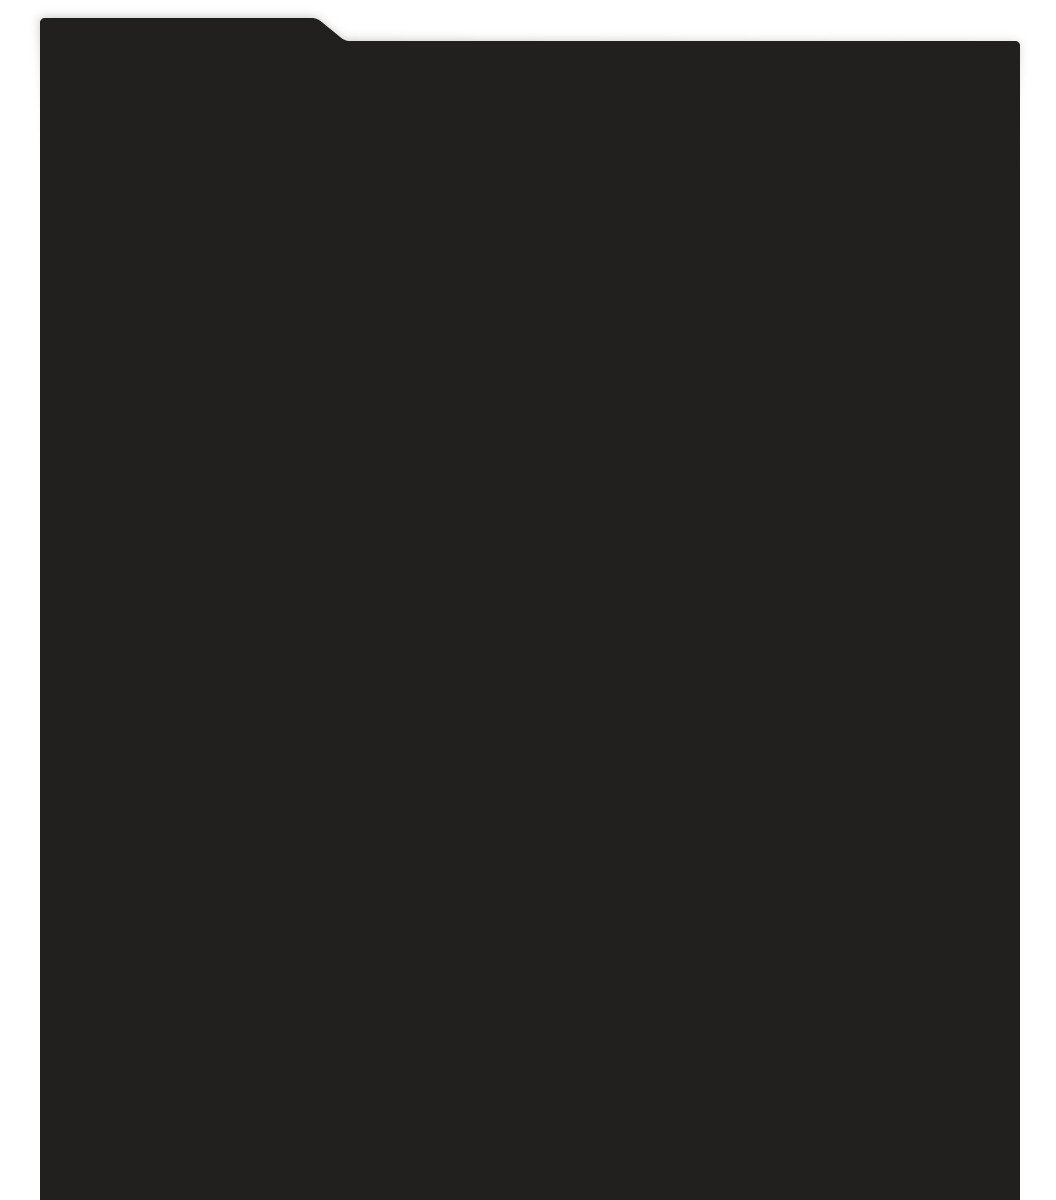
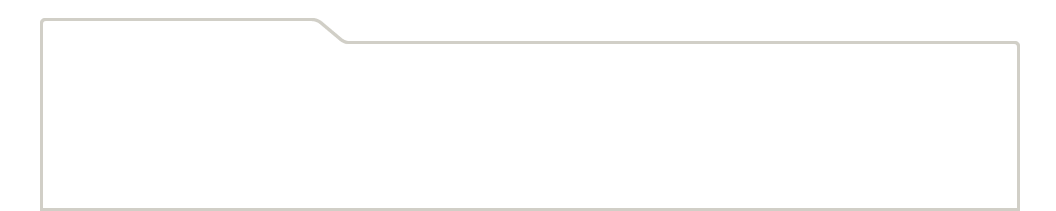
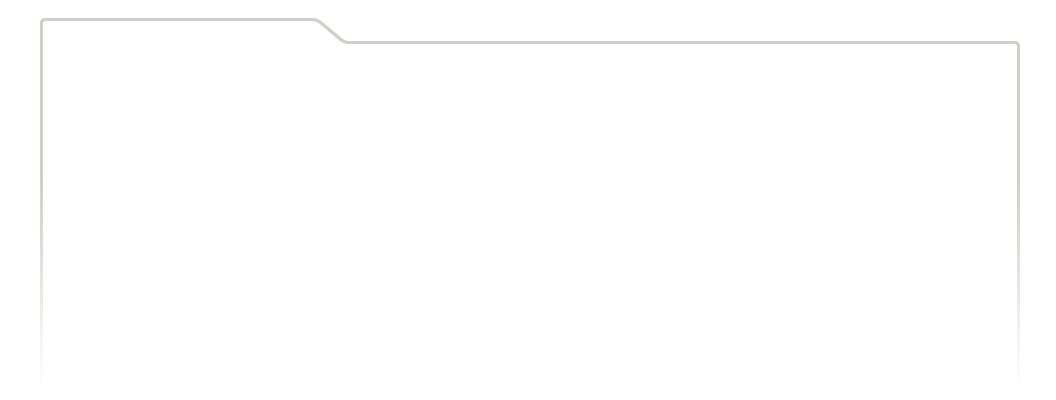
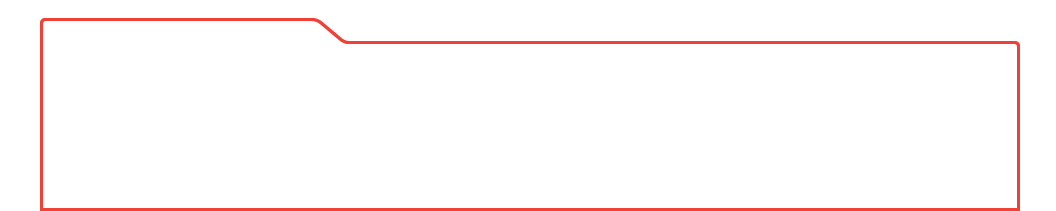
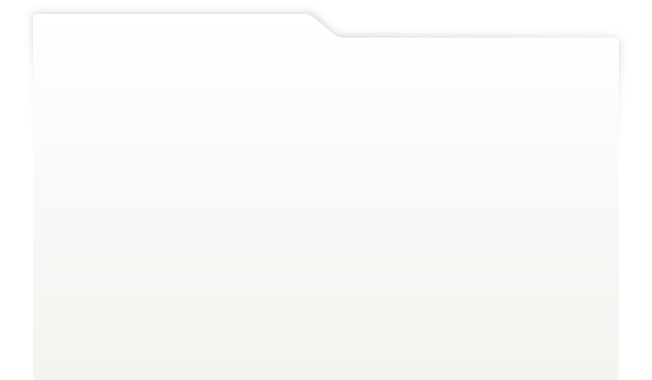
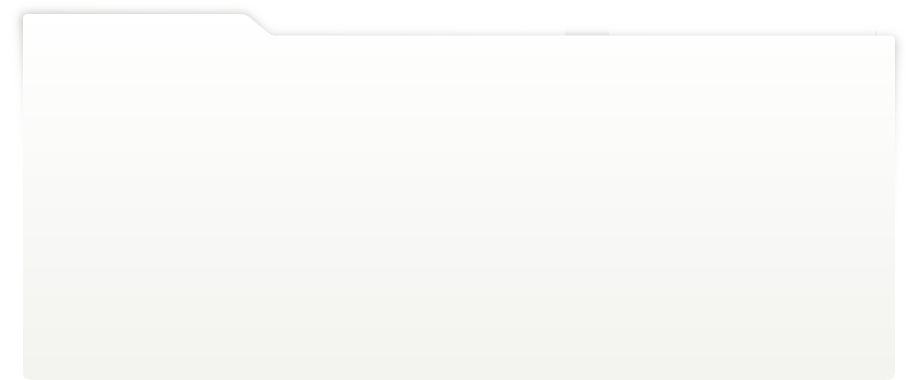
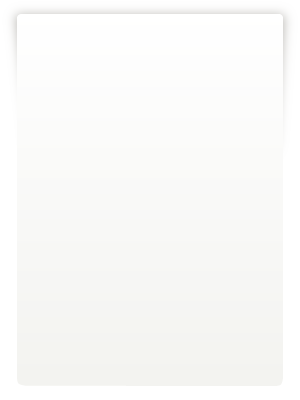
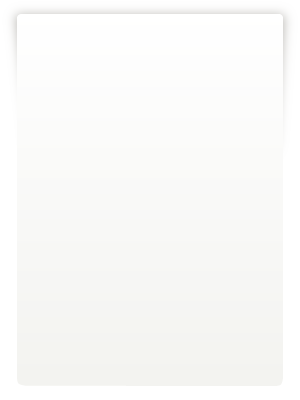
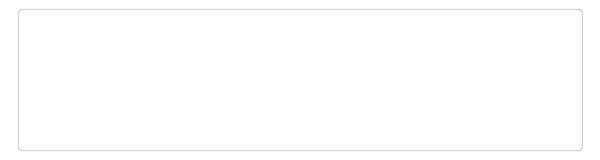
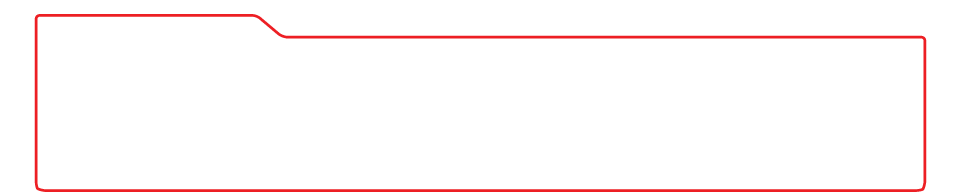
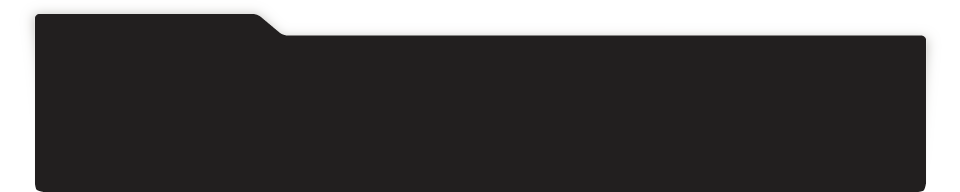
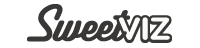
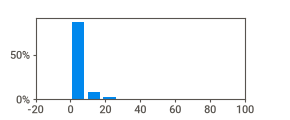
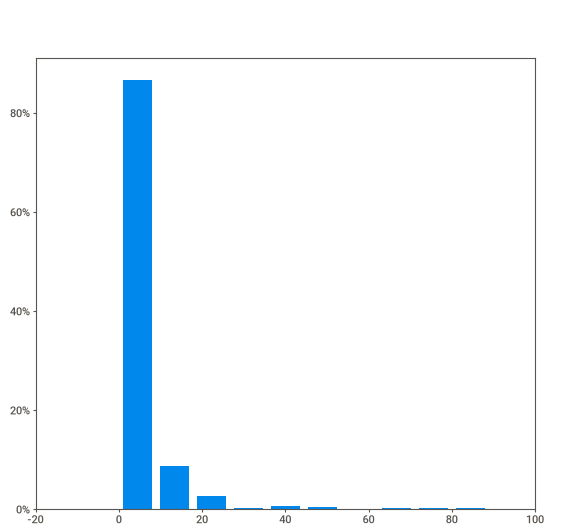
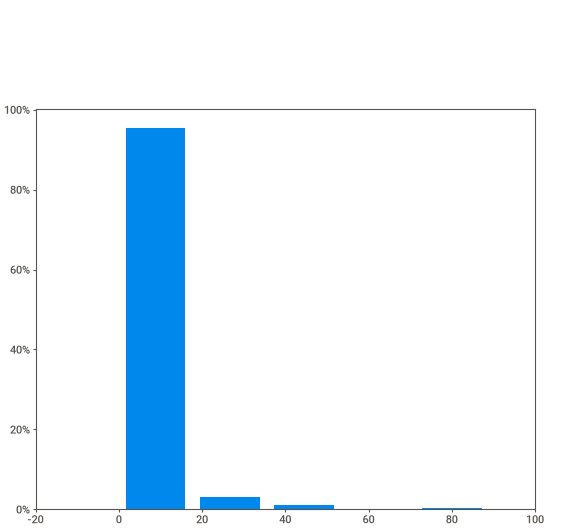
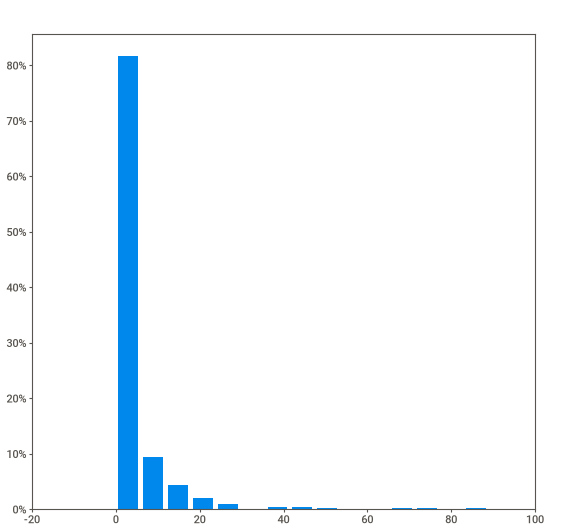
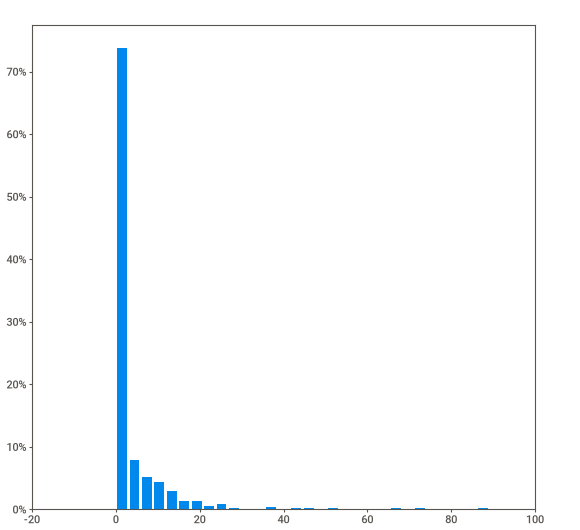
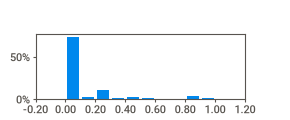
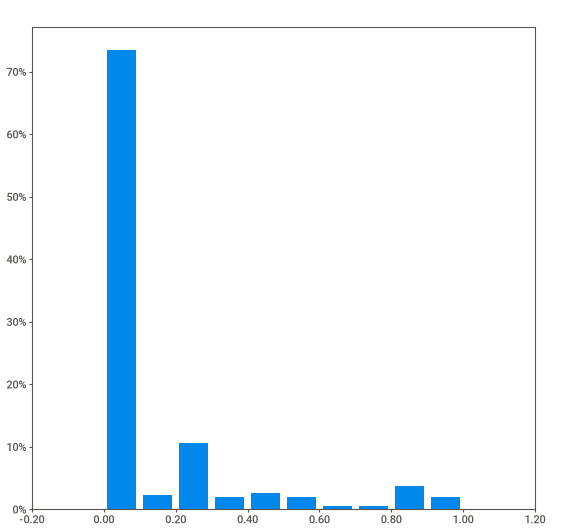
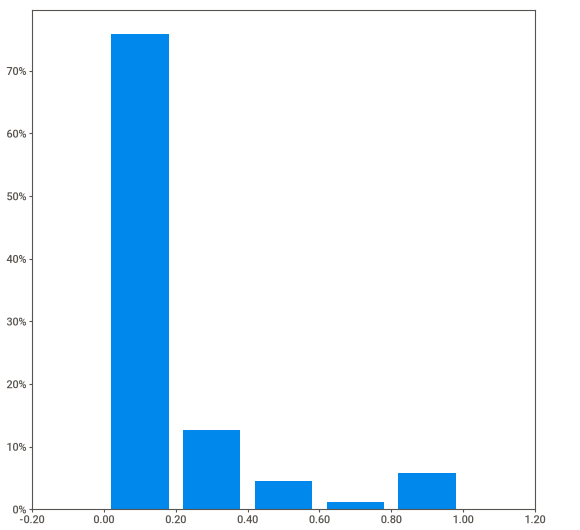
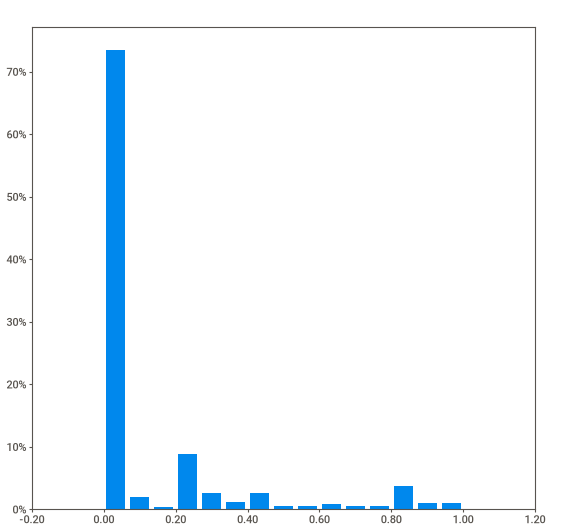
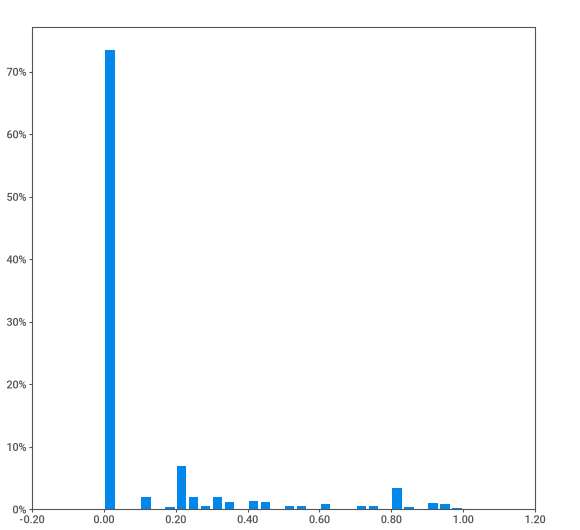
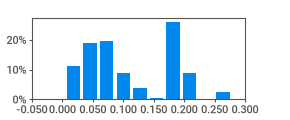
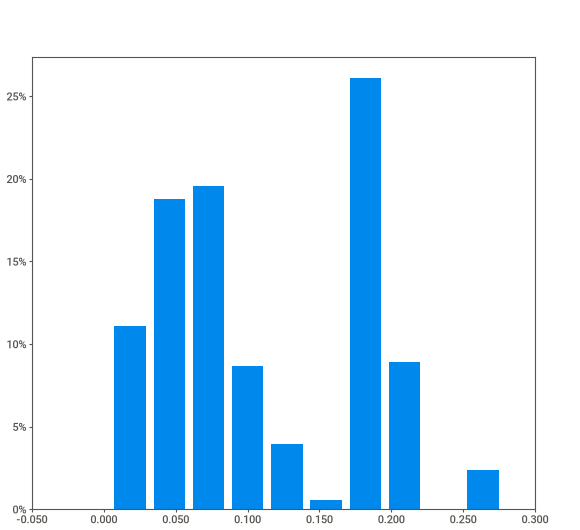
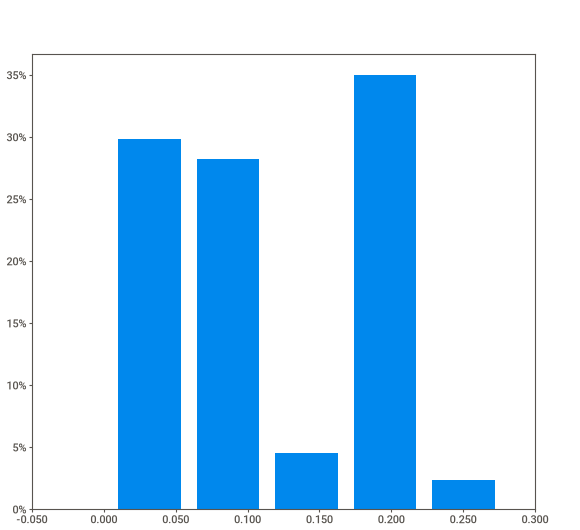
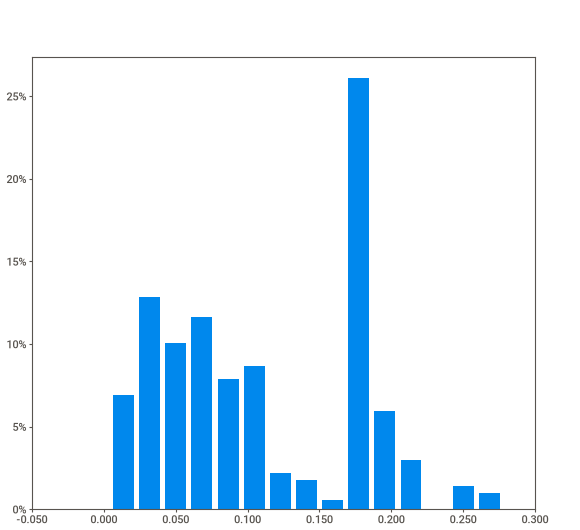
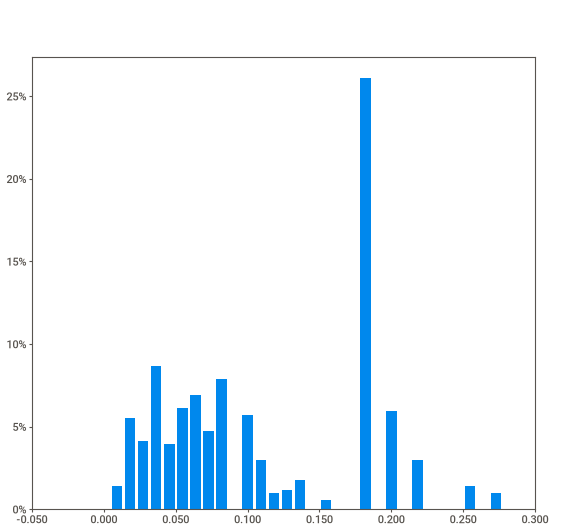
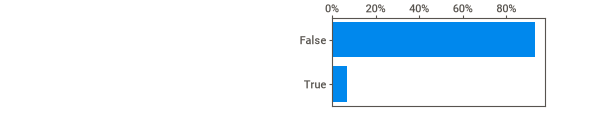
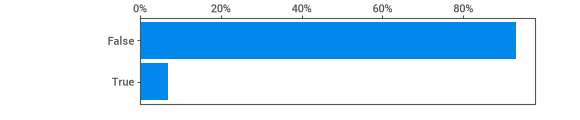
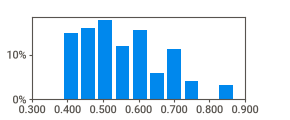
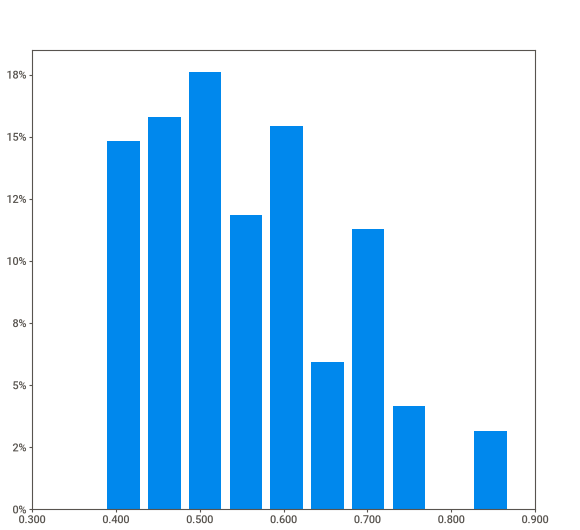
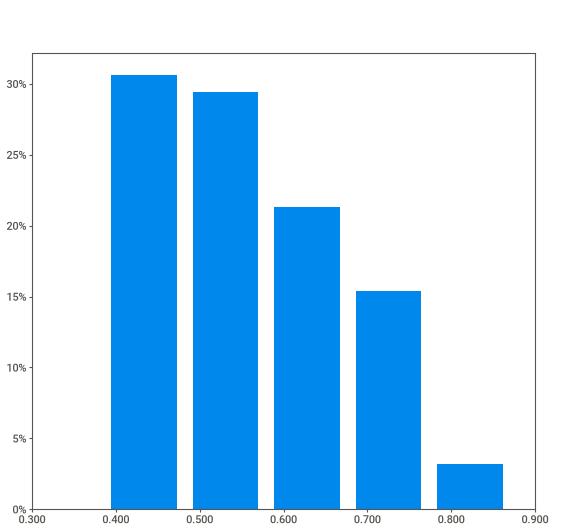
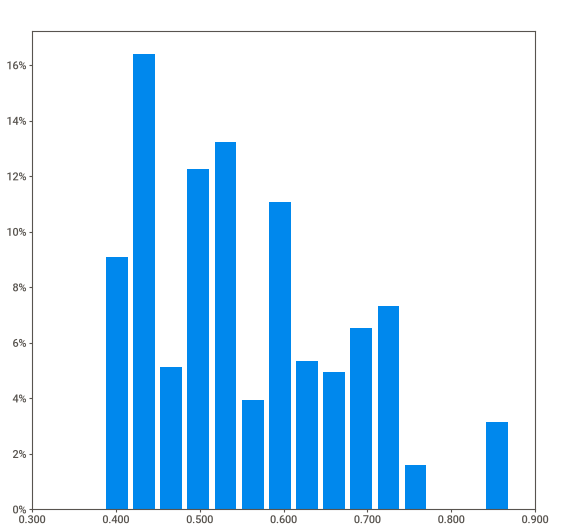
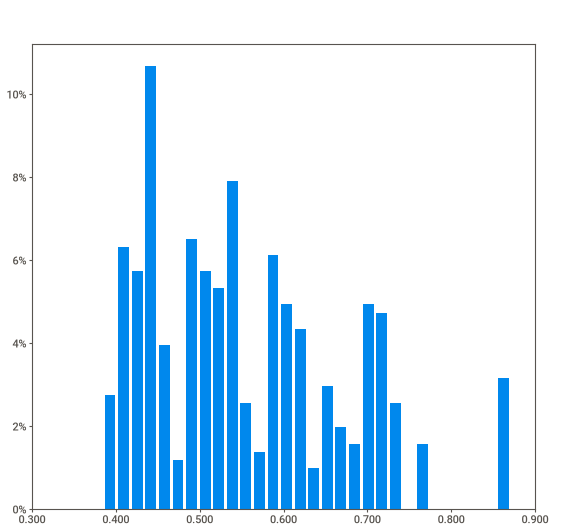
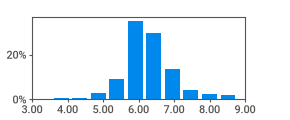
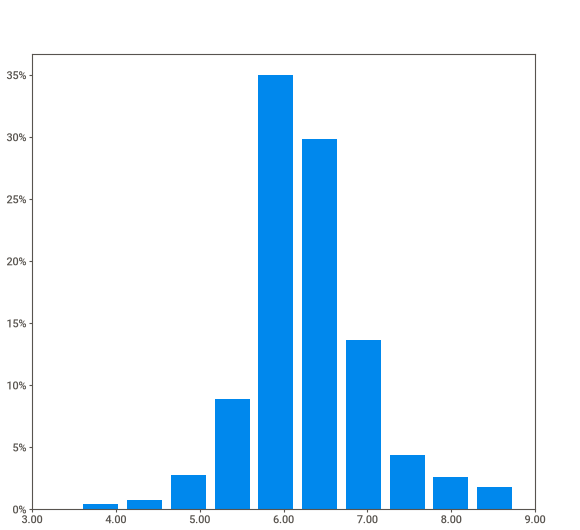
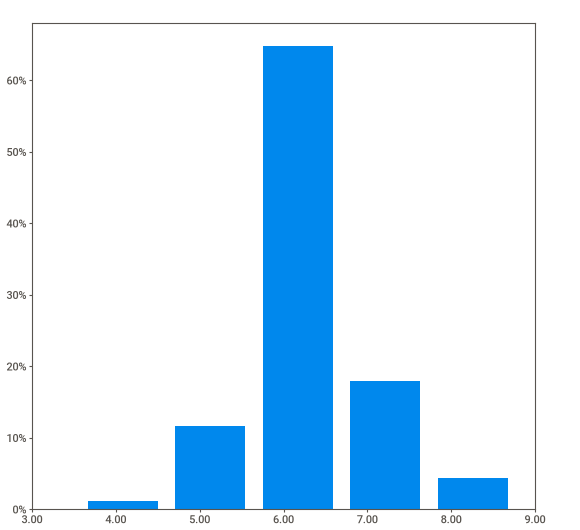
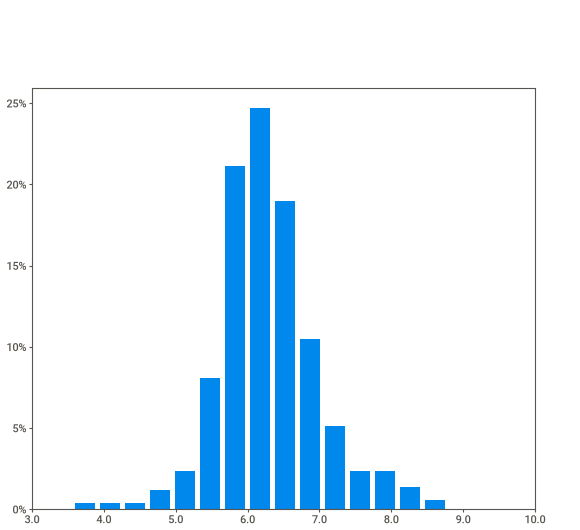
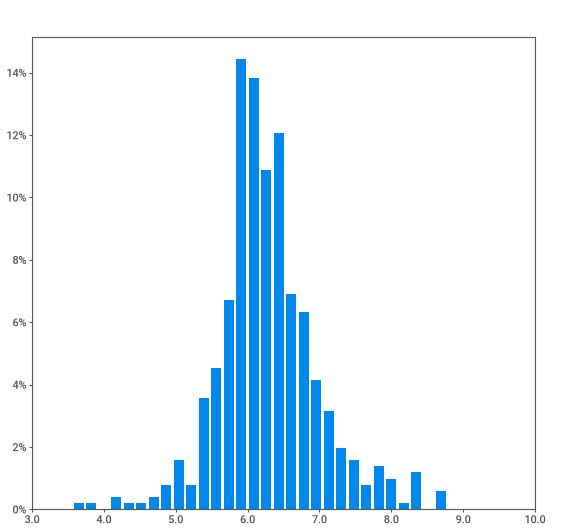
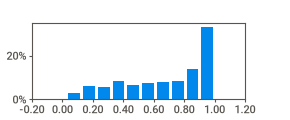
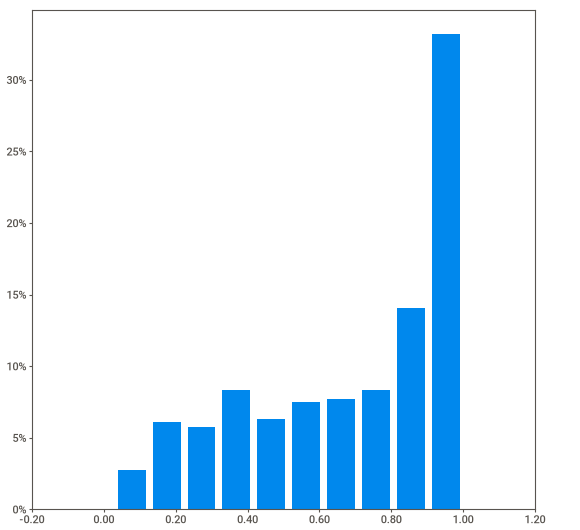
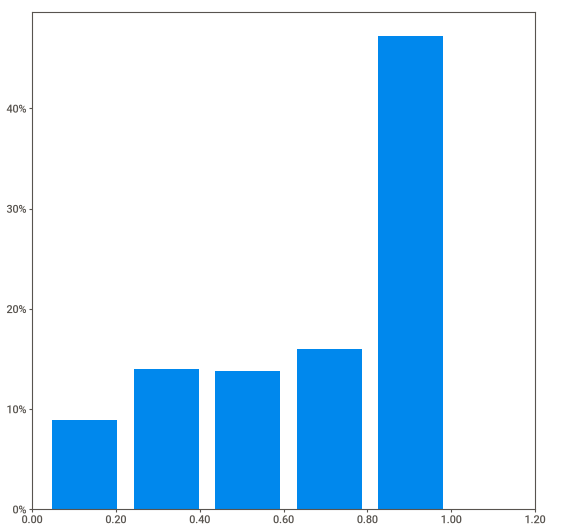
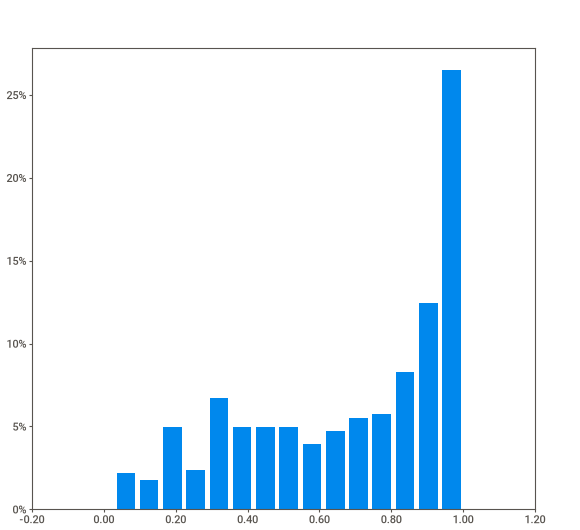
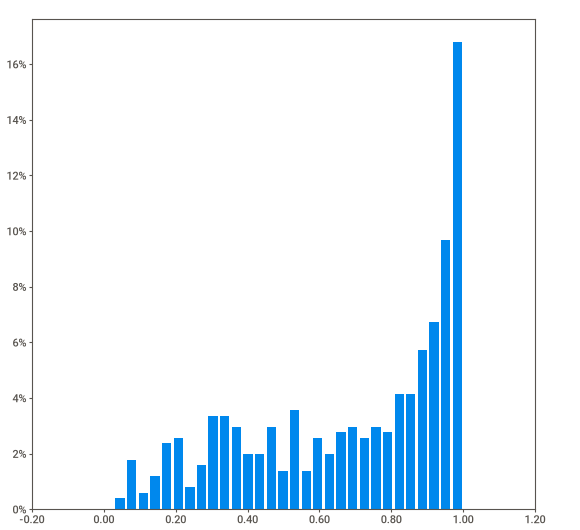
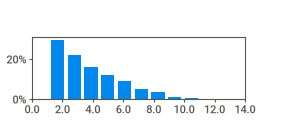
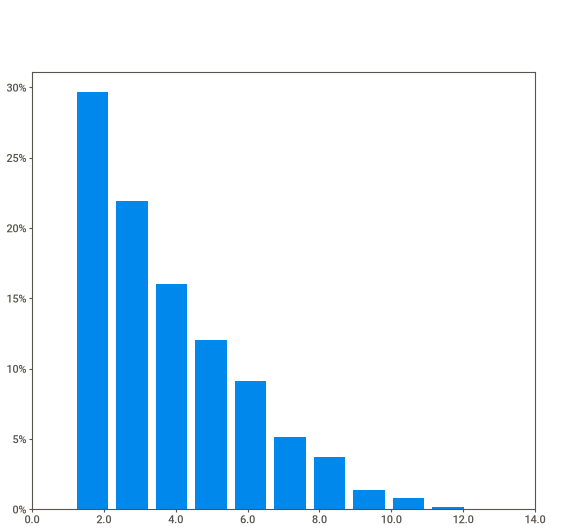
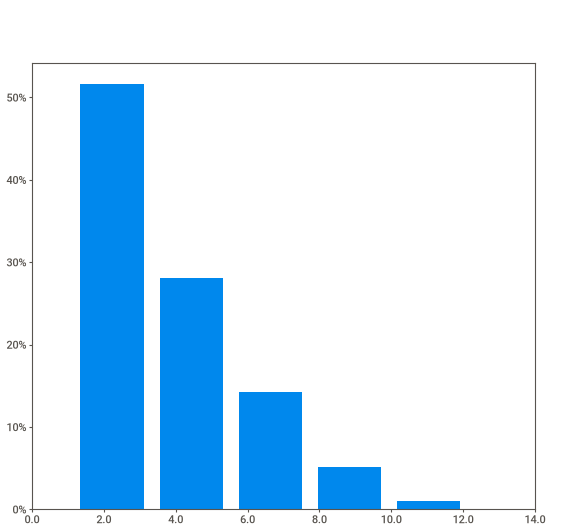
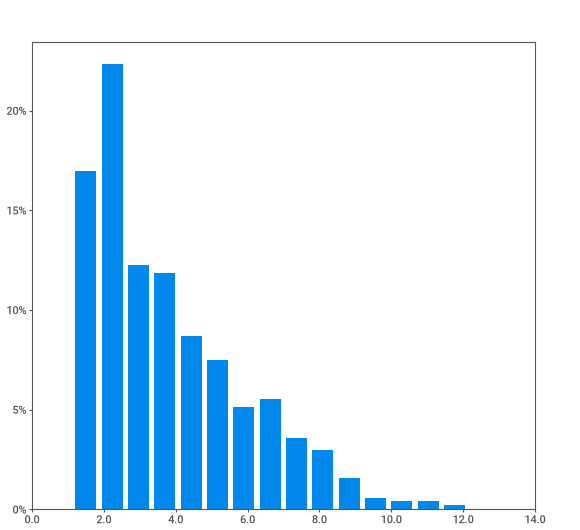
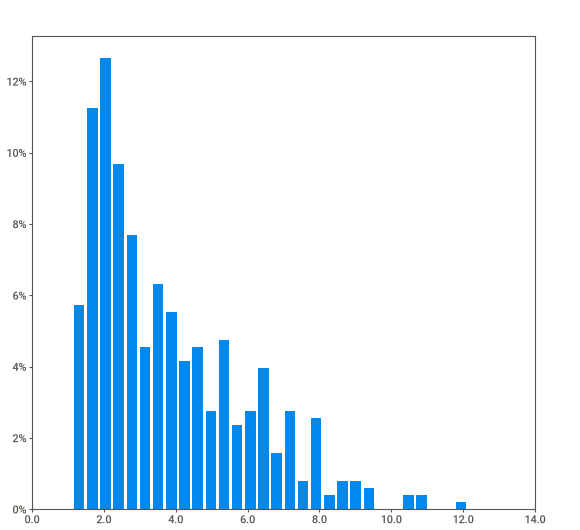
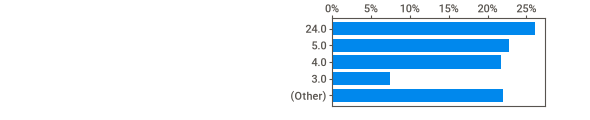
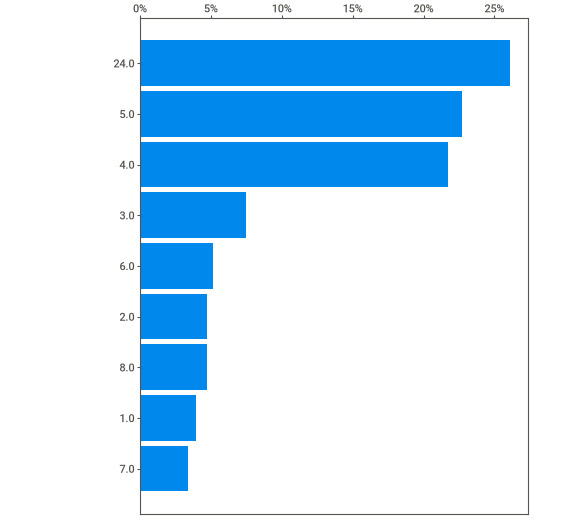
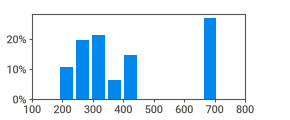
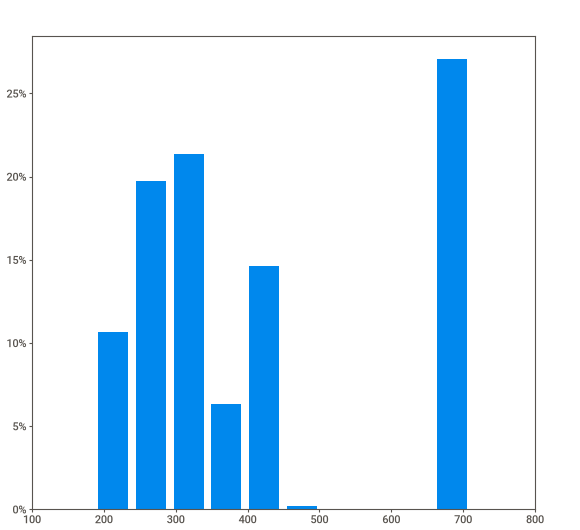
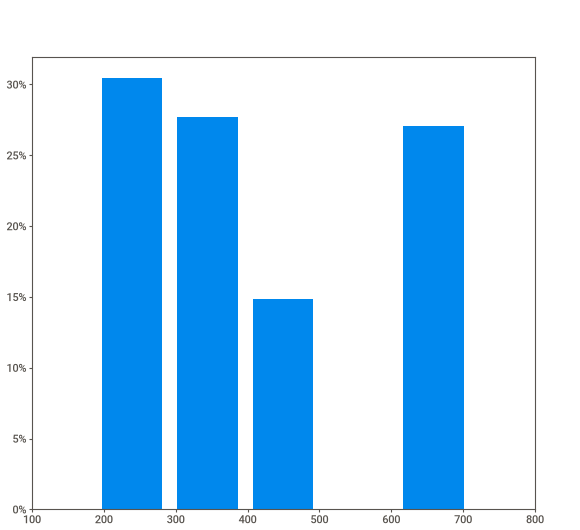
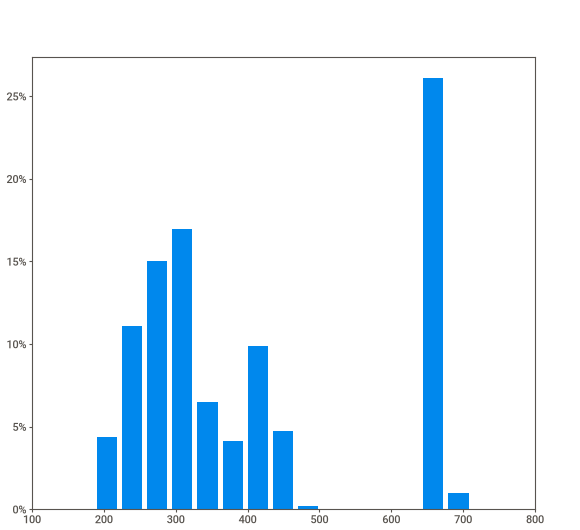
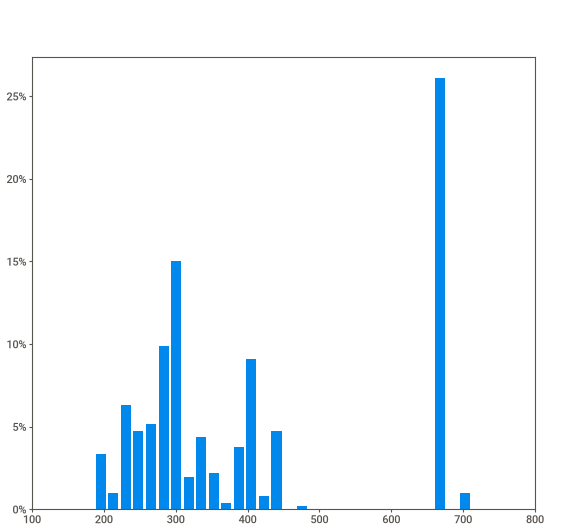
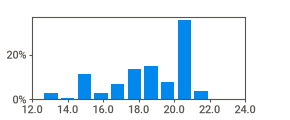
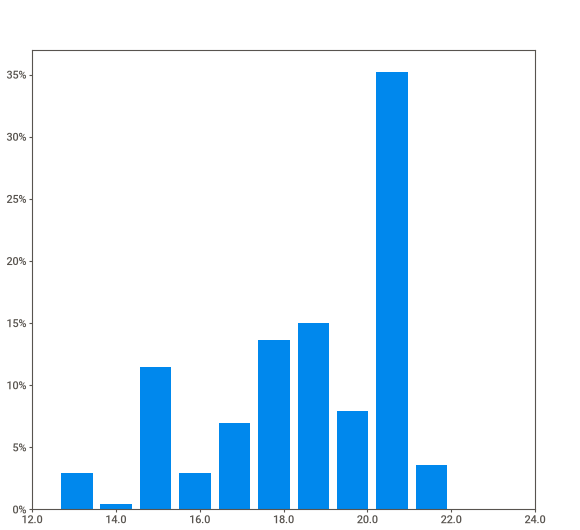
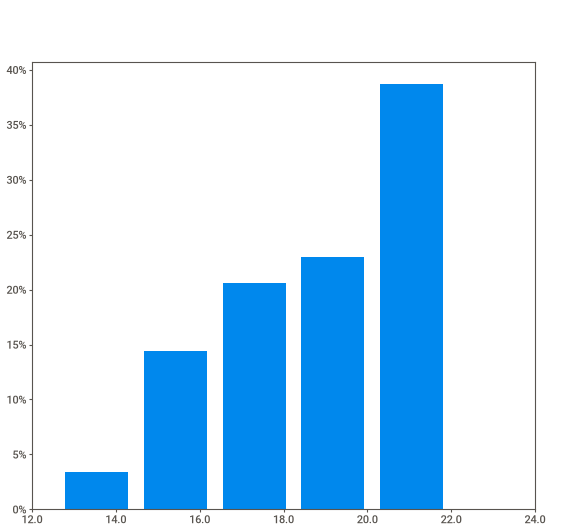
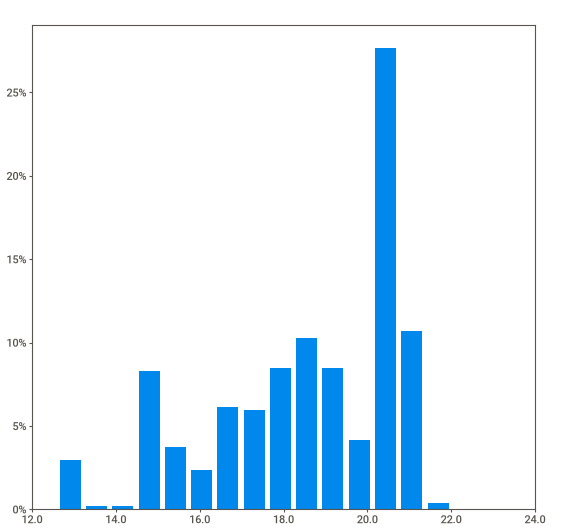
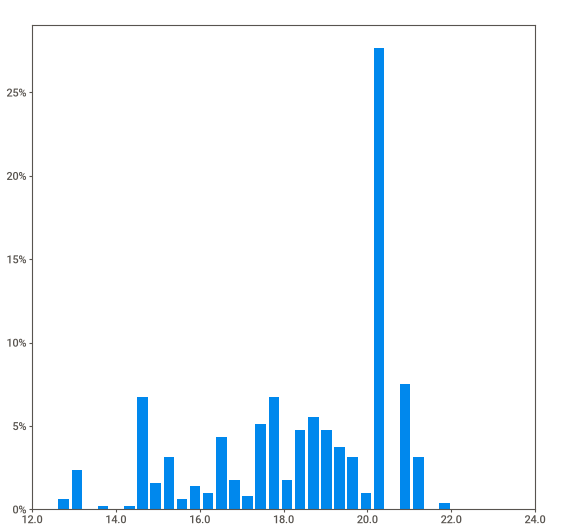
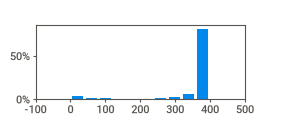
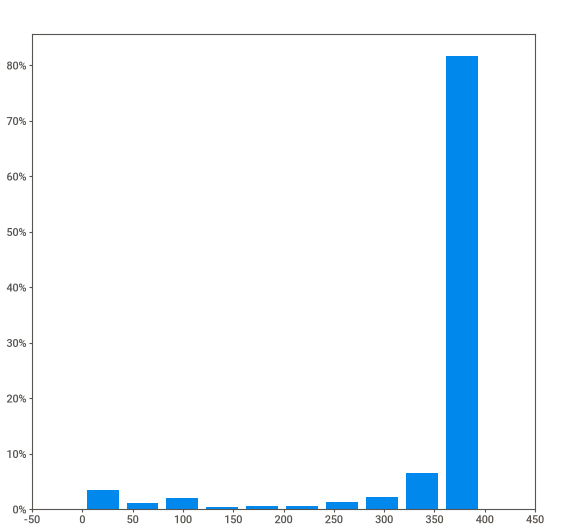
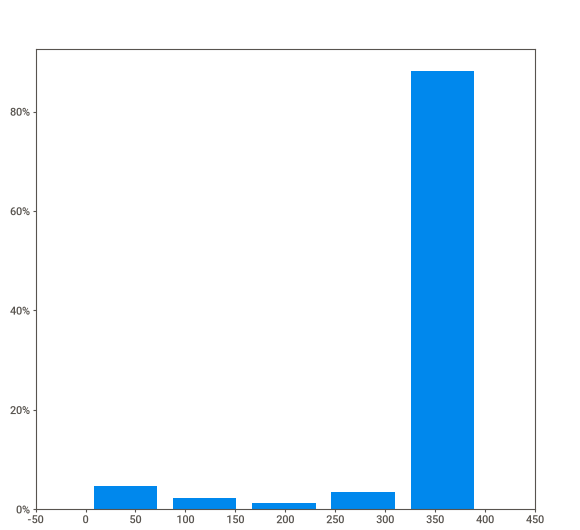
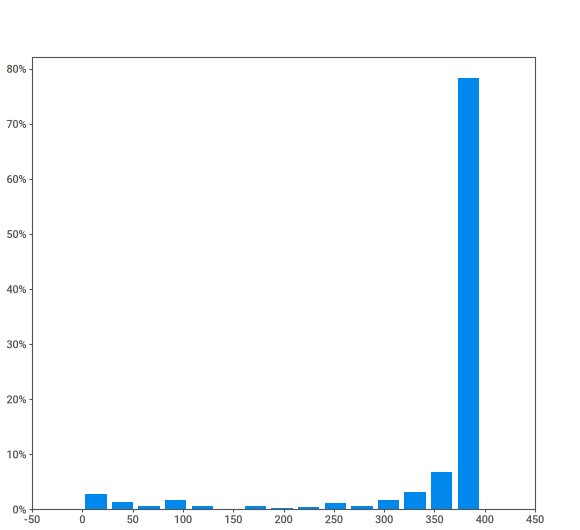
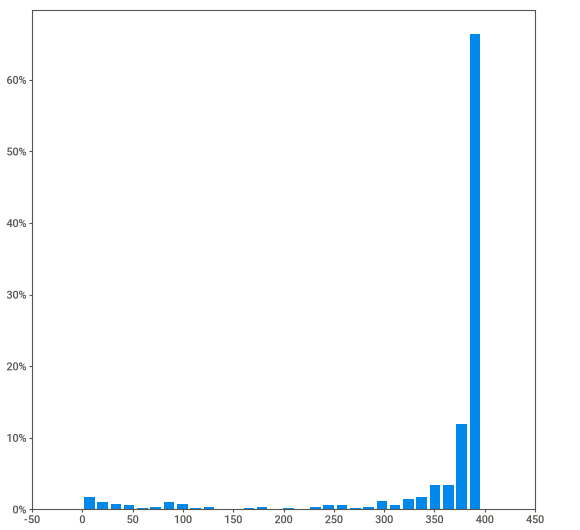
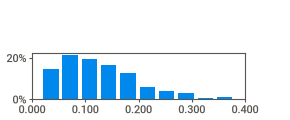
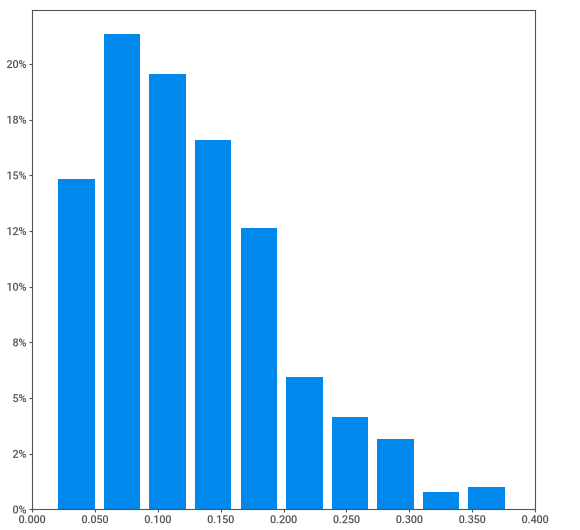
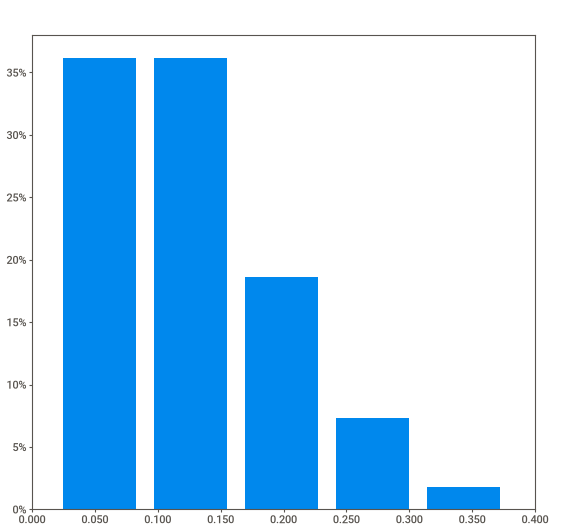
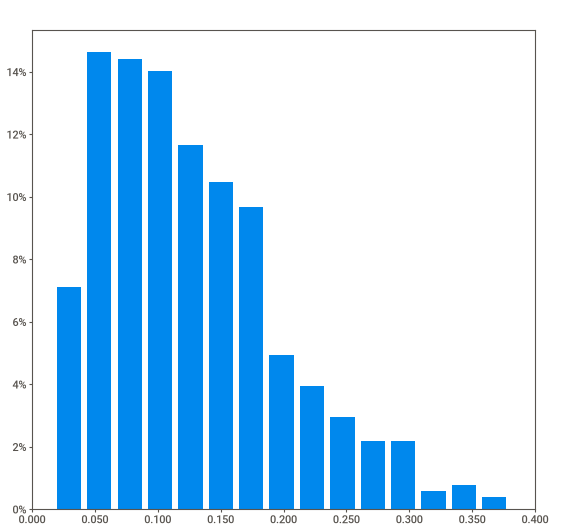
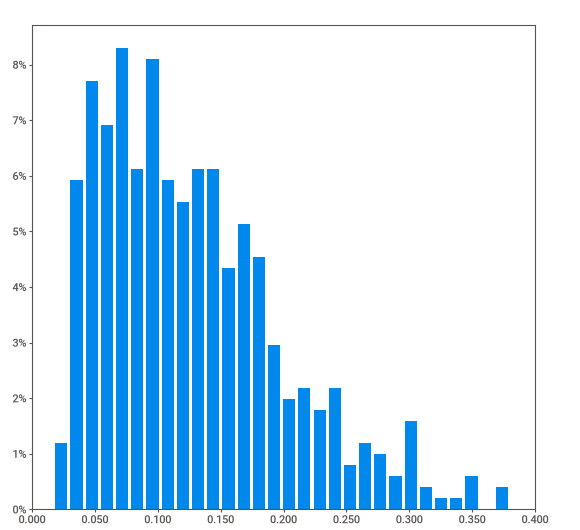
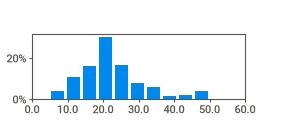
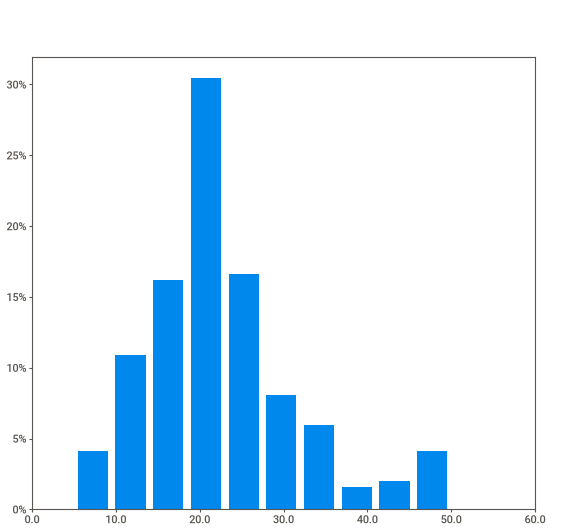
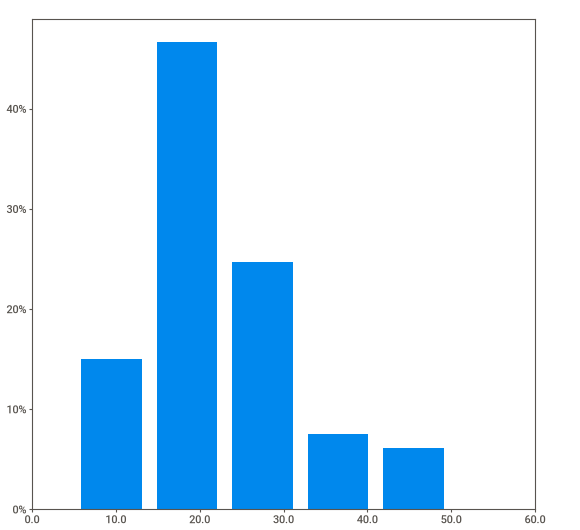
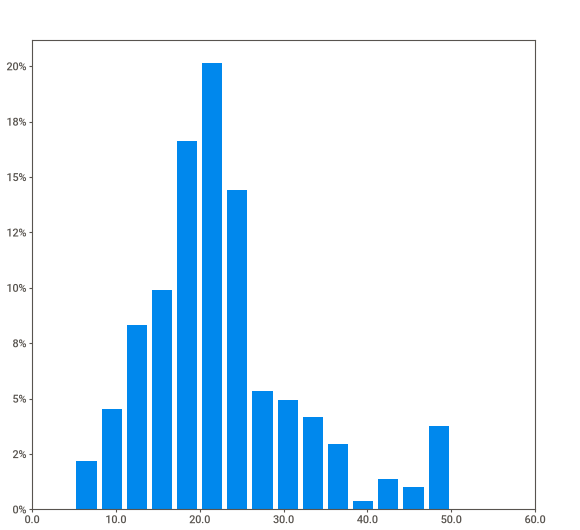
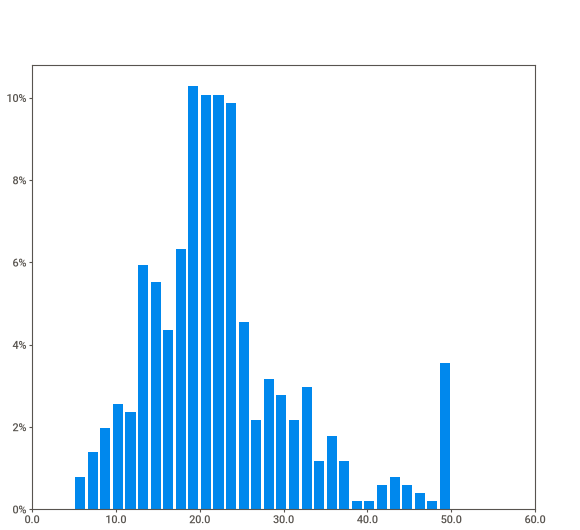
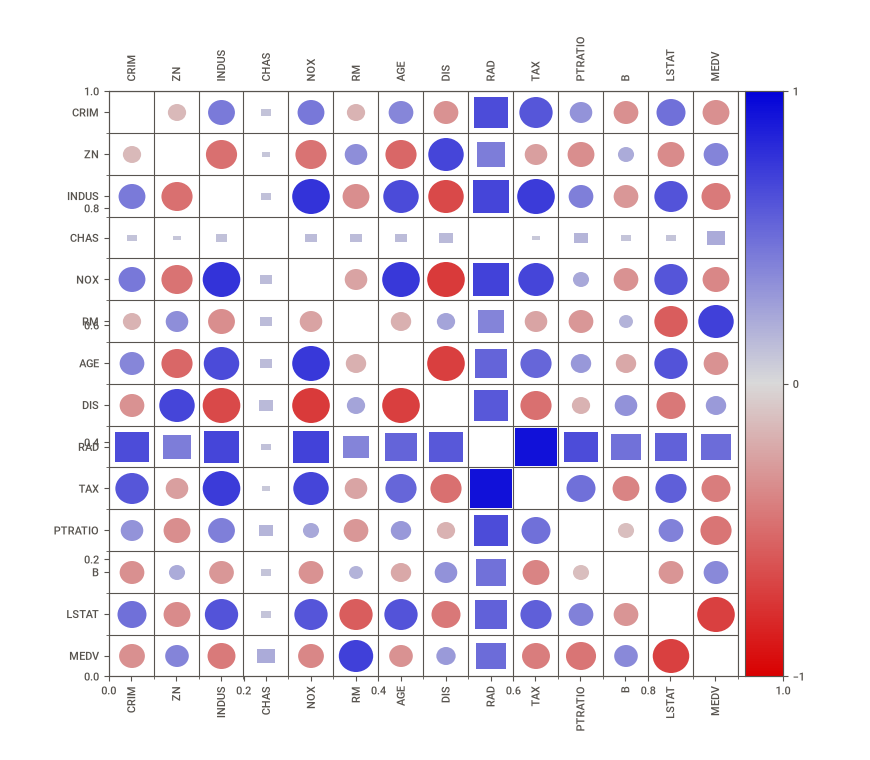
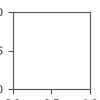

In [10]:

%pip install sweetviz

import sweetviz as sv

reporte = sv.analyze(raw_dataset)
reporte.show_notebook()